In [45]:
%%writefile requirements.txt
stable-baselines3[extra]
gymnasium
ale-py
shimmy
numpy
pandas
matplotlib
jupyter

Overwriting requirements.txt


In [46]:
!python -m pip install -q -r requirements.txt

In [47]:
%%writefile train.py
#!/usr/bin/env python
# coding: utf-8

"""
Reusable DQN training script for Atari experiments.
Train ONE experiment at a time and save:
- final model
- best checkpoint during training
- training CSV
- config JSON
- evaluation JSON
"""

import os
import csv
import json
import time
import argparse
from pathlib import Path

import ale_py  # noqa: F401
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecMonitor


class EpisodeCSVLogger(BaseCallback):
    def __init__(self, csv_path: str, verbose: int = 0):
        super().__init__(verbose)
        self.csv_path = csv_path
        self.rows = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                ep = info["episode"]
                self.rows.append(
                    {
                        "timestep": self.num_timesteps,
                        "ep_length": ep["l"],
                        "ep_reward": ep["r"],
                        "time": round(time.time(), 2),
                    }
                )
        return True

    def _on_training_end(self) -> None:
        os.makedirs(os.path.dirname(self.csv_path), exist_ok=True)
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=["timestep", "ep_length", "ep_reward", "time"],
            )
            writer.writeheader()
            writer.writerows(self.rows)


def make_cnn_env(env_id: str, seed: int, render_mode=None):
    env = make_atari_env(
        env_id,
        n_envs=1,
        seed=seed,
        env_kwargs={"render_mode": render_mode},
    )
    env = VecMonitor(env)
    env = VecFrameStack(env, n_stack=4)
    return env


def make_mlp_env(env_id: str, seed: int, render_mode=None):
    def _make():
        env = gym.make(env_id, obs_type="ram", render_mode=render_mode)
        env = Monitor(env)
        env.reset(seed=seed)
        return env

    env = DummyVecEnv([_make])
    env = VecMonitor(env)
    return env


def parse_args():
    parser = argparse.ArgumentParser(description="Train one DQN Atari experiment")
    parser.add_argument("--member", type=str, required=True)
    parser.add_argument("--experiment", type=str, required=True)
    parser.add_argument("--env-id", type=str, default="ALE/Boxing-v5")
    parser.add_argument("--policy", type=str, choices=["CnnPolicy", "MlpPolicy"], default="CnnPolicy")
    parser.add_argument("--total-timesteps", type=int, default=100_000) 
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--device", type=str, default="auto")
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument("--gamma", type=float, default=0.99)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--buffer-size", type=int, default=50_000)
    parser.add_argument("--learning-starts", type=int, default=2000) 
    parser.add_argument("--train-freq", type=int, default=4)
    parser.add_argument("--gradient-steps", type=int, default=1)
    parser.add_argument("--target-update-interval", type=int, default=10_000)
    parser.add_argument("--exploration-initial-eps", type=float, default=1.0)
    parser.add_argument("--exploration-final-eps", type=float, default=0.05)
    parser.add_argument("--exploration-fraction", type=float, default=0.10)
    parser.add_argument("--eval-freq", type=int, default=10_000)
    parser.add_argument("--eval-episodes", type=int, default=5)
    return parser.parse_args()


def main():
    args = parse_args()

    base_dir = Path("results") / args.member
    model_dir = base_dir / "models"
    log_dir = base_dir / "logs"
    table_dir = base_dir / "tables"
    experiment_dir = base_dir / args.experiment

    model_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)
    table_dir.mkdir(parents=True, exist_ok=True)
    experiment_dir.mkdir(parents=True, exist_ok=True)

    config_path = experiment_dir / f"{args.experiment}_config.json"
    training_csv_path = log_dir / f"{args.experiment}_training_metrics.csv"
    eval_json_path = experiment_dir / f"{args.experiment}_eval.json"
    final_model_path = model_dir / f"{args.experiment}.zip"
    best_model_dir = model_dir / f"{args.experiment}_best"
    eval_log_dir = experiment_dir / "eval_logs"

    config = {
        "member": args.member,
        "experiment": args.experiment,
        "env_id": args.env_id,
        "policy": args.policy,
        "total_timesteps": args.total_timesteps,
        "seed": args.seed,
        "device": args.device,
        "learning_rate": args.learning_rate,
        "gamma": args.gamma,
        "batch_size": args.batch_size,
        "buffer_size": args.buffer_size,
        "learning_starts": args.learning_starts,
        "train_freq": args.train_freq,
        "gradient_steps": args.gradient_steps,
        "target_update_interval": args.target_update_interval,
        "exploration_initial_eps": args.exploration_initial_eps,
        "exploration_final_eps": args.exploration_final_eps,
        "exploration_fraction": args.exploration_fraction,
        "eval_freq": args.eval_freq,
        "eval_episodes": args.eval_episodes,
    }
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)

    if args.policy == "CnnPolicy":
        train_env = make_cnn_env(args.env_id, seed=args.seed)
        eval_env = make_cnn_env(args.env_id, seed=args.seed + 100)
        final_eval_env = make_cnn_env(args.env_id, seed=args.seed + 200)
    else:
        train_env = make_mlp_env(args.env_id, seed=args.seed)
        eval_env = make_mlp_env(args.env_id, seed=args.seed + 100)
        final_eval_env = make_mlp_env(args.env_id, seed=args.seed + 200)

    episode_logger = EpisodeCSVLogger(str(training_csv_path))
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=str(best_model_dir),
        log_path=str(eval_log_dir),
        eval_freq=args.eval_freq,
        n_eval_episodes=args.eval_episodes,
        deterministic=True,
        render=False,
    )

    model = DQN(
        policy=args.policy,
        env=train_env,
        learning_rate=args.learning_rate,
        gamma=args.gamma,
        batch_size=args.batch_size,
        buffer_size=args.buffer_size,
        learning_starts=args.learning_starts,
        train_freq=args.train_freq,
        gradient_steps=args.gradient_steps,
        target_update_interval=args.target_update_interval,
        exploration_initial_eps=args.exploration_initial_eps,
        exploration_final_eps=args.exploration_final_eps,
        exploration_fraction=args.exploration_fraction,
        tensorboard_log=str(log_dir / "tensorboard"),
        seed=args.seed,
        device=args.device,
        verbose=1,
    )

    print("\n[START TRAINING]")
    print(json.dumps(config, indent=2))

    start_time = time.time()
    model.learn(
        total_timesteps=args.total_timesteps,
        callback=[episode_logger, eval_callback],
        progress_bar=False,
    )
    train_minutes = (time.time() - start_time) / 60.0

    model.save(str(final_model_path.with_suffix("")))

    mean_reward, std_reward = evaluate_policy(
        model,
        final_eval_env,
        n_eval_episodes=args.eval_episodes,
        deterministic=True,
    )

    eval_summary = {
        "member": args.member,
        "experiment": args.experiment,
        "policy": args.policy,
        "env_id": args.env_id,
        "mean_reward": float(mean_reward),
        "std_reward": float(std_reward),
        "train_minutes": float(train_minutes),
        "model_path": str(final_model_path),
        "best_model_path": str(best_model_dir / "best_model.zip"),
        "training_csv_path": str(training_csv_path),
        "config_path": str(config_path),
        "learning_rate": args.learning_rate,
        "gamma": args.gamma,
        "batch_size": args.batch_size,
        "buffer_size": args.buffer_size,
        "learning_starts": args.learning_starts,
        "train_freq": args.train_freq,
        "gradient_steps": args.gradient_steps,
        "target_update_interval": args.target_update_interval,
        "exploration_initial_eps": args.exploration_initial_eps,
        "exploration_final_eps": args.exploration_final_eps,
        "exploration_fraction": args.exploration_fraction,
        "seed": args.seed,
        "total_timesteps": args.total_timesteps,
    }

    with open(eval_json_path, "w", encoding="utf-8") as f:
        json.dump(eval_summary, f, indent=2)

    print("\n[END TRAINING]")
    print(f"Final model saved to: {final_model_path}")
    print(f"Best checkpoint folder: {best_model_dir}")
    print(f"Training CSV: {training_csv_path}")
    print(f"Eval summary JSON: {eval_json_path}")
    print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
    print(f"Train minutes: {train_minutes:.2f}")

    train_env.close()
    eval_env.close()
    final_eval_env.close()


if __name__ == "__main__":
    main()

Overwriting train.py


In [48]:
import os
import json
import sys
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

while not (PROJECT_ROOT / "scripts" / "train.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

MEMBER = "BestVerie"
ENV_ID = "ALE/Boxing-v5"
SEED = 42
TOTAL_TIMESTEPS = 100_000
EVAL_EPISODES = 10

TRAIN_SCRIPT = PROJECT_ROOT /"train.py"
BASE_DIR = PROJECT_ROOT / "results" / MEMBER
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)
print("Train script :", TRAIN_SCRIPT)
print("Base dir     :", BASE_DIR)
print("Train exists :", TRAIN_SCRIPT.exists())

Notebook dir : /kaggle/working
Project root : /
Train script : /train.py
Base dir     : /results/BestVerie
Train exists : False


In [49]:
experiments = [
    {
        "name": "boxing_exp01_baseline_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp02_small_batch_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 16,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp03_large_batch_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp04_low_gamma_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.95,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp05_high_gamma_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.999,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.02,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp06_gamma_zero_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.0,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp07_more_exploration_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_fraction": 0.30,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.10,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp08_less_exploration_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_fraction": 0.05,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.01,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp09_more_updates_cnn",
        "policy": "CnnPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 4
    },
    {
        "name": "boxing_exp10_baseline_mlp",
        "policy": "MlpPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    },
    {
        "name": "boxing_exp11_small_batch_mlp",
        "policy": "MlpPolicy",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 16,
        "exploration_fraction": 0.10,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "gradient_steps": 1
    }
]

print(f"Prepared {len(experiments)} Boxing experiments")

Prepared 11 Boxing experiments


In [50]:
# Helper to run one experiment through scripts/train.py
import sys
import subprocess
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

while not (PROJECT_ROOT / "train.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_SCRIPT = PROJECT_ROOT /"train.py"

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)
print("Train script :", TRAIN_SCRIPT)
print("Exists?      :", TRAIN_SCRIPT.exists())

def run_experiment(exp: dict):
    cmd = [
        sys.executable, 'train.py',
        "--member", MEMBER,
        "--experiment", exp["name"],
        "--env-id", ENV_ID,
        "--policy", exp.get("policy", "CnnPolicy"),
        "--total-timesteps", str(TOTAL_TIMESTEPS),
        "--seed", str(SEED),
        "--learning-rate", str(exp["learning_rate"]),
        "--gamma", str(exp["gamma"]),
        "--batch-size", str(exp["batch_size"]),
        "--buffer-size", str(exp.get("buffer_size", 50_000)),
        "--learning-starts", str(exp.get("learning_starts", 5_000)),
        "--train-freq", str(exp.get("train_freq", 4)),
        "--gradient-steps", str(exp.get("gradient_steps", 1)),
        "--target-update-interval", str(exp.get("target_update_interval", 10_000)),
        "--exploration-initial-eps", str(exp.get("exploration_initial_eps", 1.0)),
        "--exploration-final-eps", str(exp.get("exploration_final_eps", 0.05)),
        "--exploration-fraction", str(exp.get("exploration_fraction", 0.10)),
        "--eval-freq", "10000",
        "--eval-episodes", str(EVAL_EPISODES),
    ]

    print("\nRunning:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=str(PROJECT_ROOT),
        capture_output=True,
        text=True
    )

    print("\nSTDOUT:\n", result.stdout)
    if result.stderr:
        print("\nSTDERR:\n", result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Experiment failed with exit code {result.returncode}")

Notebook dir : /kaggle/working
Project root : /kaggle/working
Train script : /kaggle/working/train.py
Exists?      : True


In [51]:
#  Run all 10 experiments
for exp in experiments:
    run_experiment(exp)

print('All experiments finished.')



Running:
/usr/bin/python3 train.py --member BestVerie --experiment boxing_exp01_baseline_cnn --env-id ALE/Boxing-v5 --policy CnnPolicy --total-timesteps 100000 --seed 42 --learning-rate 0.0001 --gamma 0.99 --batch-size 32 --buffer-size 50000 --learning-starts 5000 --train-freq 4 --gradient-steps 1 --target-update-interval 10000 --exploration-initial-eps 1.0 --exploration-final-eps 0.05 --exploration-fraction 0.1 --eval-freq 10000 --eval-episodes 10

STDOUT:
 Using cuda device
Wrapping the env in a VecTransposeImage.

[START TRAINING]
{
  "member": "BestVerie",
  "experiment": "boxing_exp01_baseline_cnn",
  "env_id": "ALE/Boxing-v5",
  "policy": "CnnPolicy",
  "total_timesteps": 100000,
  "seed": 42,
  "device": "auto",
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "batch_size": 32,
  "buffer_size": 50000,
  "learning_starts": 5000,
  "train_freq": 4,
  "gradient_steps": 1,
  "target_update_interval": 10000,
  "exploration_initial_eps": 1.0,
  "exploration_final_eps": 0.05,
  "explorat

In [ ]:
from pathlib import Path
import json
import pandas as pd

BASE_DIR = Path("results") / "BestVerie"

In [59]:
#  Read evaluation summaries into one table
rows = []
missing = []

for exp in experiments:
    eval_path = BASE_DIR / exp['name'] / f"{exp['name']}_eval.json"
    if eval_path.is_file():
        with open(eval_path, 'r', encoding='utf-8') as f:
            rows.append(json.load(f))
    else:
        missing.append(str(eval_path))

if missing:
    print('Missing evaluation files:')
    for m in missing:
        print(' -', m)

results_df = pd.DataFrame(rows).sort_values('mean_reward', ascending=False).reset_index(drop=True)
results_df


,member,experiment,policy,env_id,mean_reward,std_reward,train_minutes,model_path,best_model_path,training_csv_path,...,buffer_size,learning_starts,train_freq,gradient_steps,target_update_interval,exploration_initial_eps,exploration_final_eps,exploration_fraction,seed,total_timesteps
0,BestVerie,boxing_exp01_baseline_cnn,CnnPolicy,ALE/Boxing-v5,5.900000,5.503635,14.233667,results/BestVerie/models/boxing_exp01_baseline...,results/BestVerie/models/boxing_exp01_baseline...,results/BestVerie/logs/boxing_exp01_baseline_c...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
1,BestVerie,boxing_exp05_high_gamma_cnn,CnnPolicy,ALE/Boxing-v5,4.700000,3.661967,14.111267,results/BestVerie/models/boxing_exp05_high_gam...,results/BestVerie/models/boxing_exp05_high_gam...,results/BestVerie/logs/boxing_exp05_high_gamma...,...,50000,5000,4,1,10000,1.0,0.02,0.10,42,100000
2,BestVerie,boxing_exp08_less_exploration_cnn,CnnPolicy,ALE/Boxing-v5,4.100000,4.504442,14.357745,results/BestVerie/models/boxing_exp08_less_exp...,results/BestVerie/models/boxing_exp08_less_exp...,results/BestVerie/logs/boxing_exp08_less_explo...,...,50000,5000,4,1,10000,1.0,0.01,0.05,42,100000
3,BestVerie,boxing_exp02_small_batch_cnn,CnnPolicy,ALE/Boxing-v5,3.800000,5.268776,13.622996,results/BestVerie/models/boxing_exp02_small_ba...,results/BestVerie/models/boxing_exp02_small_ba...,results/BestVerie/logs/boxing_exp02_small_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
4,BestVerie,boxing_exp04_low_gamma_cnn,CnnPolicy,ALE/Boxing-v5,1.200000,3.919183,14.075312,results/BestVerie/models/boxing_exp04_low_gamm...,results/BestVerie/models/boxing_exp04_low_gamm...,results/BestVerie/logs/boxing_exp04_low_gamma_...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
5,BestVerie,boxing_exp06_gamma_zero_cnn,CnnPolicy,ALE/Boxing-v5,-0.300000,6.325346,14.162903,results/BestVerie/models/boxing_exp06_gamma_ze...,results/BestVerie/models/boxing_exp06_gamma_ze...,results/BestVerie/logs/boxing_exp06_gamma_zero...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
6,BestVerie,boxing_exp03_large_batch_cnn,CnnPolicy,ALE/Boxing-v5,-0.600000,3.292416,14.748706,results/BestVerie/models/boxing_exp03_large_ba...,results/BestVerie/models/boxing_exp03_large_ba...,results/BestVerie/logs/boxing_exp03_large_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
7,BestVerie,boxing_exp07_more_exploration_cnn,CnnPolicy,ALE/Boxing-v5,-0.700000,5.080354,13.960359,results/BestVerie/models/boxing_exp07_more_exp...,results/BestVerie/models/boxing_exp07_more_exp...,results/BestVerie/logs/boxing_exp07_more_explo...,...,50000,5000,4,1,10000,1.0,0.10,0.30,42,100000
8,BestVerie,boxing_exp09_more_updates_cnn,CnnPolicy,ALE/Boxing-v5,-1.300000,4.267318,19.489908,results/BestVerie/models/boxing_exp09_more_upd...,results/BestVerie/models/boxing_exp09_more_upd...,results/BestVerie/logs/boxing_exp09_more_updat...,...,50000,5000,4,4,10000,1.0,0.05,0.10,42,100000
9,BestVerie,boxing_exp11_small_batch_mlp,MlpPolicy,ALE/Boxing-v5,-14.400000,5.642694,7.036411,results/BestVerie/models/boxing_exp11_small_ba...,results/BestVerie/models/boxing_exp11_small_ba...,results/BestVerie/logs/boxing_exp11_small_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000


In [60]:
#  Save results table
results_csv = TABLE_DIR / f'{MEMBER}_boxing_results.csv'
results_df.to_csv(results_csv, index=False)
print(f'Saved results table to: {results_csv}')
results_df


Saved results table to: /results/BestVerie/tables/BestVerie_boxing_results.csv


,member,experiment,policy,env_id,mean_reward,std_reward,train_minutes,model_path,best_model_path,training_csv_path,...,buffer_size,learning_starts,train_freq,gradient_steps,target_update_interval,exploration_initial_eps,exploration_final_eps,exploration_fraction,seed,total_timesteps
0,BestVerie,boxing_exp01_baseline_cnn,CnnPolicy,ALE/Boxing-v5,5.900000,5.503635,14.233667,results/BestVerie/models/boxing_exp01_baseline...,results/BestVerie/models/boxing_exp01_baseline...,results/BestVerie/logs/boxing_exp01_baseline_c...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
1,BestVerie,boxing_exp05_high_gamma_cnn,CnnPolicy,ALE/Boxing-v5,4.700000,3.661967,14.111267,results/BestVerie/models/boxing_exp05_high_gam...,results/BestVerie/models/boxing_exp05_high_gam...,results/BestVerie/logs/boxing_exp05_high_gamma...,...,50000,5000,4,1,10000,1.0,0.02,0.10,42,100000
2,BestVerie,boxing_exp08_less_exploration_cnn,CnnPolicy,ALE/Boxing-v5,4.100000,4.504442,14.357745,results/BestVerie/models/boxing_exp08_less_exp...,results/BestVerie/models/boxing_exp08_less_exp...,results/BestVerie/logs/boxing_exp08_less_explo...,...,50000,5000,4,1,10000,1.0,0.01,0.05,42,100000
3,BestVerie,boxing_exp02_small_batch_cnn,CnnPolicy,ALE/Boxing-v5,3.800000,5.268776,13.622996,results/BestVerie/models/boxing_exp02_small_ba...,results/BestVerie/models/boxing_exp02_small_ba...,results/BestVerie/logs/boxing_exp02_small_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
4,BestVerie,boxing_exp04_low_gamma_cnn,CnnPolicy,ALE/Boxing-v5,1.200000,3.919183,14.075312,results/BestVerie/models/boxing_exp04_low_gamm...,results/BestVerie/models/boxing_exp04_low_gamm...,results/BestVerie/logs/boxing_exp04_low_gamma_...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
5,BestVerie,boxing_exp06_gamma_zero_cnn,CnnPolicy,ALE/Boxing-v5,-0.300000,6.325346,14.162903,results/BestVerie/models/boxing_exp06_gamma_ze...,results/BestVerie/models/boxing_exp06_gamma_ze...,results/BestVerie/logs/boxing_exp06_gamma_zero...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
6,BestVerie,boxing_exp03_large_batch_cnn,CnnPolicy,ALE/Boxing-v5,-0.600000,3.292416,14.748706,results/BestVerie/models/boxing_exp03_large_ba...,results/BestVerie/models/boxing_exp03_large_ba...,results/BestVerie/logs/boxing_exp03_large_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000
7,BestVerie,boxing_exp07_more_exploration_cnn,CnnPolicy,ALE/Boxing-v5,-0.700000,5.080354,13.960359,results/BestVerie/models/boxing_exp07_more_exp...,results/BestVerie/models/boxing_exp07_more_exp...,results/BestVerie/logs/boxing_exp07_more_explo...,...,50000,5000,4,1,10000,1.0,0.10,0.30,42,100000
8,BestVerie,boxing_exp09_more_updates_cnn,CnnPolicy,ALE/Boxing-v5,-1.300000,4.267318,19.489908,results/BestVerie/models/boxing_exp09_more_upd...,results/BestVerie/models/boxing_exp09_more_upd...,results/BestVerie/logs/boxing_exp09_more_updat...,...,50000,5000,4,4,10000,1.0,0.05,0.10,42,100000
9,BestVerie,boxing_exp11_small_batch_mlp,MlpPolicy,ALE/Boxing-v5,-14.400000,5.642694,7.036411,results/BestVerie/models/boxing_exp11_small_ba...,results/BestVerie/models/boxing_exp11_small_ba...,results/BestVerie/logs/boxing_exp11_small_batc...,...,50000,5000,4,1,10000,1.0,0.05,0.10,42,100000


In [61]:
# Identify Best's best model
if results_df.empty:
    raise ValueError('No results found. Run the experiments first.')

best_row = results_df.iloc[0]

best_experiment_name = best_row['experiment']
best_mean_reward = best_row['mean_reward']
best_model_path = best_row['model_path']

print('Best experiment:', best_experiment_name)
print('Best mean reward:', best_mean_reward)
print('Best model path:', best_model_path)

Best experiment: boxing_exp01_baseline_cnn
Best mean reward: 5.900000095367432
Best model path: results/BestVerie/models/boxing_exp01_baseline_cnn.zip


In [62]:
#  Save best summary JSON
best_summary_path = TABLE_DIR / f'{MEMBER}_best_summary.json'
with open(best_summary_path, 'w', encoding='utf-8') as f:
    json.dump({'member': MEMBER, 'best_experiment': best_experiment_name, 'best_mean_reward': float(best_mean_reward), 'best_model_path': best_model_path}, f, indent=2)
print(f'Saved best summary to: {best_summary_path}')


Saved best summary to: /results/BestVerie/tables/BestVerie_best_summary.json


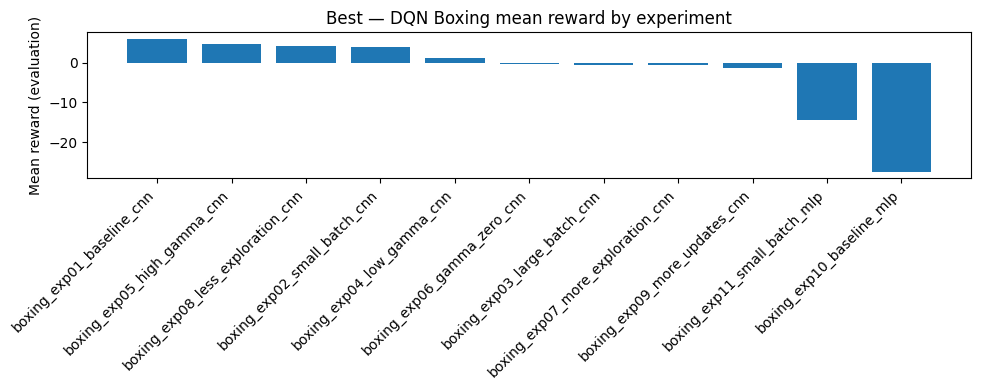

In [63]:
#  Visualization 1 — mean reward by experiment
_df = results_df.copy().sort_values('mean_reward', ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(_df['experiment'], _df['mean_reward'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean reward (evaluation)')
plt.title('Best — DQN Boxing mean reward by experiment')
plt.tight_layout()
plt.show()


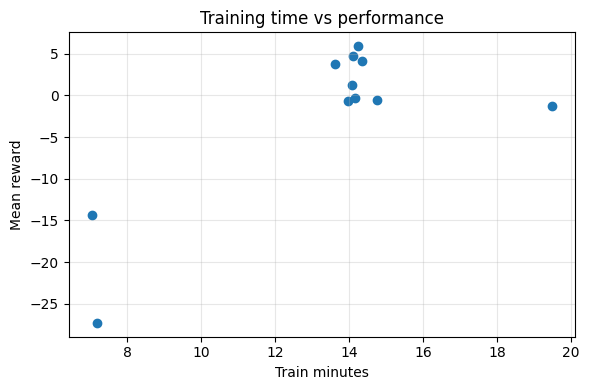

In [64]:
# Visualization 2 — training time vs performance
plt.figure(figsize=(6, 4))
plt.scatter(results_df['train_minutes'], results_df['mean_reward'])
plt.xlabel('Train minutes')
plt.ylabel('Mean reward')
plt.title('Training time vs performance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [83]:
%%writefile play.py
#!/usr/bin/env python
# coding: utf-8

import argparse
from pathlib import Path
from collections import deque

import ale_py  # noqa: F401
import gymnasium as gym
import numpy as np

from stable_baselines3 import DQN

gym.register_envs(ale_py)


def parse_args():
    parser = argparse.ArgumentParser(description="Play a trained Atari DQN model")
    parser.add_argument("--model-path", type=str, required=True)
    parser.add_argument("--env-id", type=str, required=True)
    parser.add_argument("--policy", type=str, choices=["CnnPolicy", "MlpPolicy"], required=True)
    parser.add_argument("--episodes", type=int, default=3)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--render-mode", type=str, default="rgb_array", choices=["human", "rgb_array", "None"])
    parser.add_argument("--record", action="store_true")
    return parser.parse_args()


def normalize_render_mode(render_mode: str):
    return None if render_mode == "None" else render_mode


def make_base_env(env_id: str, policy: str, render_mode=None, video_folder=None):
    kwargs = {"render_mode": render_mode}
    if policy == "MlpPolicy":
        kwargs["obs_type"] = "ram"

    env = gym.make(env_id, **kwargs)

    if video_folder:
        env = gym.wrappers.RecordVideo(
            env,
            video_folder=video_folder,
            episode_trigger=lambda episode_id: True,
            disable_logger=False,
        )

    env = gym.wrappers.RecordEpisodeStatistics(env)
    return env


def preprocess_obs_for_cnn(obs):
    # obs shape: (210, 160, 3) typically
    # grayscale + resize to 84x84 like Atari preprocessing expectations
    import cv2

    gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    return resized


def stack_reset(env):
    obs, info = env.reset()
    processed = preprocess_obs_for_cnn(obs)
    frames = deque([processed] * 4, maxlen=4)
    stacked = np.stack(frames, axis=0)
    return obs, info, frames, stacked


def stack_step(env, action, frames):
    obs, reward, terminated, truncated, info = env.step(action)
    processed = preprocess_obs_for_cnn(obs)
    frames.append(processed)
    stacked = np.stack(frames, axis=0)
    return obs, reward, terminated, truncated, info, frames, stacked


def main():
    args = parse_args()
    render_mode = normalize_render_mode(args.render_mode)

    model_path = Path(args.model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    video_folder = None
    if args.record:
        video_folder = "play_videos"

    env = make_base_env(
        env_id=args.env_id,
        policy=args.policy,
        render_mode=render_mode,
        video_folder=video_folder,
    )

    model = DQN.load(str(model_path))

    print("[PLAYING MODEL]")
    print(f"Model path: {model_path}")
    print(f"Environment: {args.env_id}")
    print(f"Policy: {args.policy}")
    print(f"Episodes: {args.episodes}")
    print(f"Render mode: {render_mode}")
    print(f"Recording: {args.record}")

    episode_rewards = []

    for ep in range(args.episodes):
        if args.policy == "CnnPolicy":
            _, _, frames, model_obs = stack_reset(env)
        else:
            model_obs, _ = env.reset()

        done = False
        ep_reward = 0.0
        step_count = 0

        while not done:
            action, _ = model.predict(model_obs, deterministic=True)

            if args.policy == "CnnPolicy":
                _, reward, terminated, truncated, _, frames, model_obs = stack_step(env, int(action), frames)
            else:
                model_obs, reward, terminated, truncated, _ = env.step(int(action))

            ep_reward += float(reward)
            step_count += 1
            done = terminated or truncated

        print(f"Episode {ep + 1}: reward = {ep_reward:.2f}, steps = {step_count}")
        episode_rewards.append(ep_reward)

    env.close()

    print("\n[PLAY COMPLETE]")
    print("Episode rewards:", episode_rewards)
    if episode_rewards:
        print(f"Average reward: {np.mean(episode_rewards):.2f}")


if __name__ == "__main__":
    main()

Overwriting play.py


In [84]:
!ls results/BestVerie/models


boxing_exp01_baseline_cnn_best	   boxing_exp06_gamma_zero_cnn.zip
boxing_exp01_baseline_cnn.zip	   boxing_exp07_more_exploration_cnn_best
boxing_exp02_small_batch_cnn_best  boxing_exp07_more_exploration_cnn.zip
boxing_exp02_small_batch_cnn.zip   boxing_exp08_less_exploration_cnn_best
boxing_exp03_large_batch_cnn_best  boxing_exp08_less_exploration_cnn.zip
boxing_exp03_large_batch_cnn.zip   boxing_exp09_more_updates_cnn_best
boxing_exp04_low_gamma_cnn_best    boxing_exp09_more_updates_cnn.zip
boxing_exp04_low_gamma_cnn.zip	   boxing_exp10_baseline_mlp_best
boxing_exp05_high_gamma_cnn_best   boxing_exp10_baseline_mlp.zip
boxing_exp05_high_gamma_cnn.zip    boxing_exp11_small_batch_mlp_best
boxing_exp06_gamma_zero_cnn_best   boxing_exp11_small_batch_mlp.zip


In [85]:
!python play.py \
  --model-path results/BestVerie/models/boxing_exp01_baseline_cnn.zip \
  --env-id ALE/Boxing-v5 \
  --policy CnnPolicy \
  --episodes 3 \
  --render-mode rgb_array \
  --record

2026-03-19 16:12:39.380618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773936759.403638     732 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773936759.410608     732 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773936759.427932     732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773936759.427964     732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773936759.427968     732 computation_placer.cc:177] computation placer alr

In [86]:
!zip -r dqn_project.zip train.py play.py results play_videos

  adding: train.py (deflated 74%)
  adding: play.py (deflated 64%)
  adding: results/ (stored 0%)
  adding: results/BestVerie/ (stored 0%)
  adding: results/BestVerie/boxing_exp06_gamma_zero_cnn/ (stored 0%)
  adding: results/BestVerie/boxing_exp06_gamma_zero_cnn/eval_logs/ (stored 0%)
  adding: results/BestVerie/boxing_exp06_gamma_zero_cnn/eval_logs/evaluations.npz (deflated 65%)
  adding: results/BestVerie/boxing_exp06_gamma_zero_cnn/boxing_exp06_gamma_zero_cnn_config.json (deflated 48%)
  adding: results/BestVerie/boxing_exp06_gamma_zero_cnn/boxing_exp06_gamma_zero_cnn_eval.json (deflated 58%)
  adding: results/BestVerie/boxing_exp05_high_gamma_cnn/ (stored 0%)
  adding: results/BestVerie/boxing_exp05_high_gamma_cnn/eval_logs/ (stored 0%)
  adding: results/BestVerie/boxing_exp05_high_gamma_cnn/eval_logs/evaluations.npz (deflated 65%)
  adding: results/BestVerie/boxing_exp05_high_gamma_cnn/boxing_exp05_high_gamma_cnn_config.json (deflated 48%)
  adding: results/BestVerie/boxing_exp05

In [88]:
!pwd
!ls

/kaggle/working
dqn_project.zip  play.py  play_videos  requirements.txt  results  train.py


In [89]:
from IPython.display import FileLink
FileLink('dqn_project.zip')

/kaggle/working/dqn_project.zip